In [410]:
from pyexpat import features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import calendar
from pandas.api.types import CategoricalDtype
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split


In [411]:
#Loading of dataset
BASE_DIR = Path.cwd().parent
data_path=BASE_DIR/"data"/"raw.csv"
df=pd.read_csv(data_path)

In [412]:
#EDA(Exploratory data analysis)
df.shape

(2930, 82)

In [413]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [414]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [415]:
df.isnull().sum()

Order                 0
PID                   0
MS SubClass           0
MS Zoning             0
Lot Frontage        490
Lot Area              0
Street                0
Alley              2732
Lot Shape             0
Land Contour          0
Utilities             0
Lot Config            0
Land Slope            0
Neighborhood          0
Condition 1           0
Condition 2           0
Bldg Type             0
House Style           0
Overall Qual          0
Overall Cond          0
Year Built            0
Year Remod/Add        0
Roof Style            0
Roof Matl             0
Exterior 1st          0
Exterior 2nd          0
Mas Vnr Type       1775
Mas Vnr Area         23
Exter Qual            0
Exter Cond            0
Foundation            0
Bsmt Qual            80
Bsmt Cond            80
Bsmt Exposure        83
BsmtFin Type 1       80
BsmtFin SF 1          1
BsmtFin Type 2       81
BsmtFin SF 2          1
Bsmt Unf SF           1
Total Bsmt SF         1
Heating               0
Heating QC      

In [416]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [417]:
# know your data: Understand all the features that are important in relation to achieving your target value
# year built
# pool area
# lot area
# etc

#Data Integration : combine data if you have more than 1 data files to train model

In [418]:
#Most null value features
# Alley
# pool qc
# fence
# Misc feature
# fireplace Qu

In [419]:
int_features=df.select_dtypes(include=['int64']).columns
print("no of features for int64 data:",len(int_features))
print("Integer features names:",int_features.tolist())

no of features for int64 data: 28
Integer features names: ['Order', 'PID', 'MS SubClass', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']


In [420]:
float_features= df.select_dtypes(include=['float64']).columns
print("Float features names:",len(float_features))
print("float features names:",float_features.tolist())

Float features names: 11
float features names: ['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Yr Blt', 'Garage Cars', 'Garage Area']


In [421]:
cat_features=df.select_dtypes(include=['object']).columns
print("Cat features names:",len(cat_features))
print("Cat features names:",cat_features.tolist())

Cat features names: 43
Cat features names: ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']


Data cleaning / Data preprocessing
what are the methods to handle missing values??
Ignore missing values/Delete rows
Fill missing value manually
Global constant
Measure of central tendancy(mean, median, mode)
Measure of central tendancy for each class
Most probable value(ML algorithms:KNN,Naive BAYES : DO NO GET AFFECTED BY MISSING VALUES/NULL VALUES)

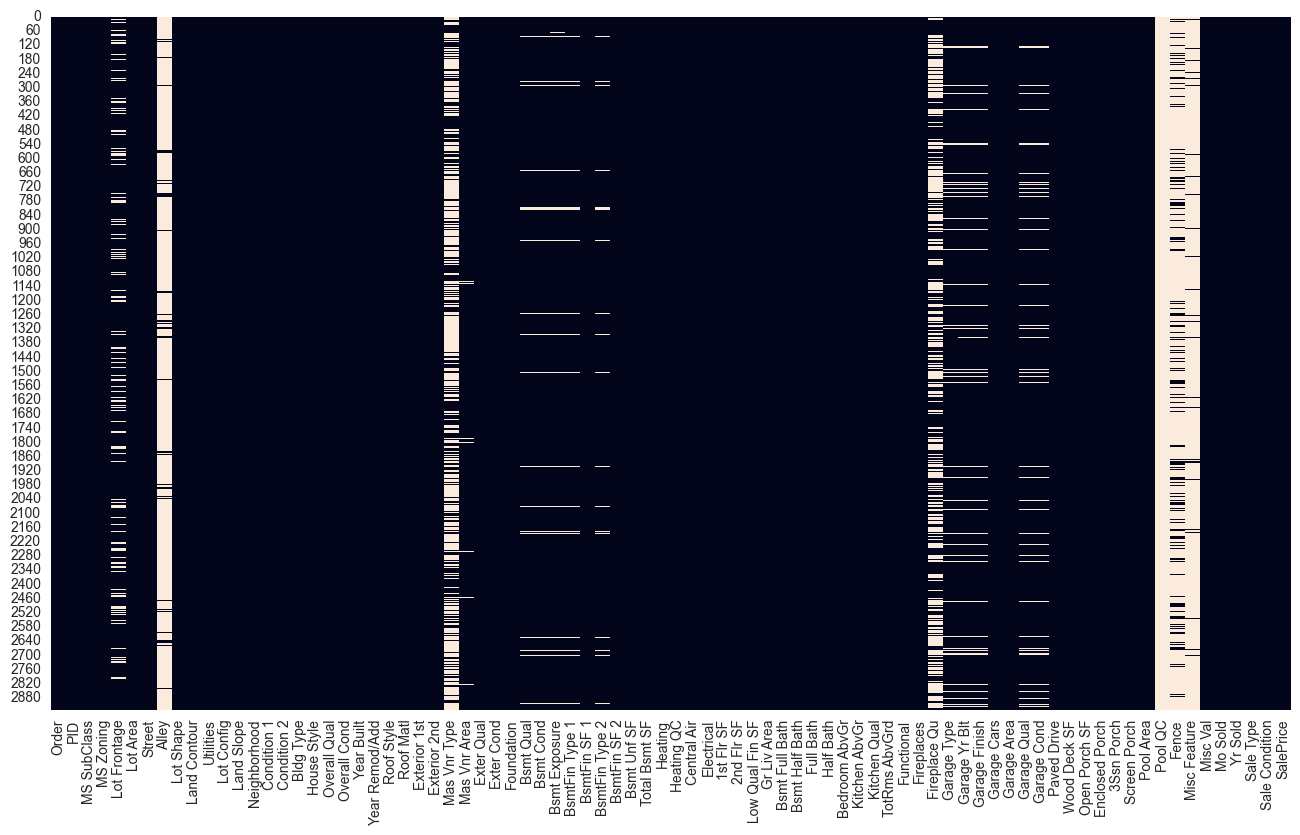

In [422]:
BASE_DIR = Path.cwd().parent   # move from notebooks → project root
FIG_DIR = BASE_DIR / "figures"
plt.figure(figsize=(16, 9))
sns.heatmap(df.isnull(), cbar=False)
plt.savefig(FIG_DIR / "heatmap_df_null_values.png", bbox_inches="tight")

Get the null value percentage for every feature

In [423]:
null_count=df.isnull().sum()
null_count

Order                 0
PID                   0
MS SubClass           0
MS Zoning             0
Lot Frontage        490
Lot Area              0
Street                0
Alley              2732
Lot Shape             0
Land Contour          0
Utilities             0
Lot Config            0
Land Slope            0
Neighborhood          0
Condition 1           0
Condition 2           0
Bldg Type             0
House Style           0
Overall Qual          0
Overall Cond          0
Year Built            0
Year Remod/Add        0
Roof Style            0
Roof Matl             0
Exterior 1st          0
Exterior 2nd          0
Mas Vnr Type       1775
Mas Vnr Area         23
Exter Qual            0
Exter Cond            0
Foundation            0
Bsmt Qual            80
Bsmt Cond            80
Bsmt Exposure        83
BsmtFin Type 1       80
BsmtFin SF 1          1
BsmtFin Type 2       81
BsmtFin SF 2          1
Bsmt Unf SF           1
Total Bsmt SF         1
Heating               0
Heating QC      

In [424]:
null_percentage=df.isnull().sum()/df.shape[0]*100
null_percentage = null_percentage[null_percentage > 0]
print(null_percentage.sort_values(ascending=False))

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Cond        5.426621
Garage Qual        5.426621
Garage Finish      5.426621
Garage Yr Blt      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Half Bath     0.068259
Bsmt Full Bath     0.068259
BsmtFin SF 1       0.034130
Garage Cars        0.034130
Garage Area        0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
dtype: float64


Drop columns/Features
"As per domain knowledge, we will not drop features, instead of null value we will add constant value"

As per observation we will not drop any feature from dataset
important feature like POOLQC, Lotfrontage have most null values but are important features to affect final price

##Missing value imputation

In [425]:
missing_value_features=null_percentage[null_percentage > 0]
missing_value_features

Lot Frontage      16.723549
Alley             93.242321
Mas Vnr Type      60.580205
Mas Vnr Area       0.784983
Bsmt Qual          2.730375
Bsmt Cond          2.730375
Bsmt Exposure      2.832765
BsmtFin Type 1     2.730375
BsmtFin SF 1       0.034130
BsmtFin Type 2     2.764505
BsmtFin SF 2       0.034130
Bsmt Unf SF        0.034130
Total Bsmt SF      0.034130
Electrical         0.034130
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
Fireplace Qu      48.532423
Garage Type        5.358362
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Cars        0.034130
Garage Area        0.034130
Garage Qual        5.426621
Garage Cond        5.426621
Pool QC           99.556314
Fence             80.477816
Misc Feature      96.382253
dtype: float64

In [426]:
cat_NA_feat=missing_value_features[missing_value_features.keys().isin(cat_features)]
cat_NA_feat

Alley             93.242321
Mas Vnr Type      60.580205
Bsmt Qual          2.730375
Bsmt Cond          2.730375
Bsmt Exposure      2.832765
BsmtFin Type 1     2.730375
BsmtFin Type 2     2.764505
Electrical         0.034130
Fireplace Qu      48.532423
Garage Type        5.358362
Garage Finish      5.426621
Garage Qual        5.426621
Garage Cond        5.426621
Pool QC           99.556314
Fence             80.477816
Misc Feature      96.382253
dtype: float64

In [427]:
int_NA_feat=missing_value_features[missing_value_features.keys().isin(int_features)]
len(int_NA_feat)

0

In [428]:
float_NA_feat=missing_value_features[missing_value_features.keys().isin(float_features)]
len(float_NA_feat)
float_NA_feat

Lot Frontage      16.723549
Mas Vnr Area       0.784983
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Bsmt Unf SF        0.034130
Total Bsmt SF      0.034130
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
Garage Yr Blt      5.426621
Garage Cars        0.034130
Garage Area        0.034130
dtype: float64

###Handling ALley = 93.242321

In [429]:
df_mvi = df.copy()
df_mvi.shape

(2930, 82)

In [430]:
df_mvi["Alley"].value_counts()

Alley
Grvl    120
Pave     78
Name: count, dtype: int64

In [431]:
alley_constant="NA"
df_mvi["Alley"].replace(np.nan, "alley_constant", inplace=True)
df_mvi["Alley"].isnull().sum()

0

Handling LotFrontage = 16.723549

In [432]:
def boxhistplot(df, figsize=(16, 5)):
    plt.figure(figsize=figsize)
    plt.subplot(121)
    sns.boxplot(df)
    plt.subplot(122)
    sns.distplot(df)


/var/folders/ps/8m068t8n4wg8plb13ns3t63r0000gn/T/ipykernel_64721/2983875093.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df)


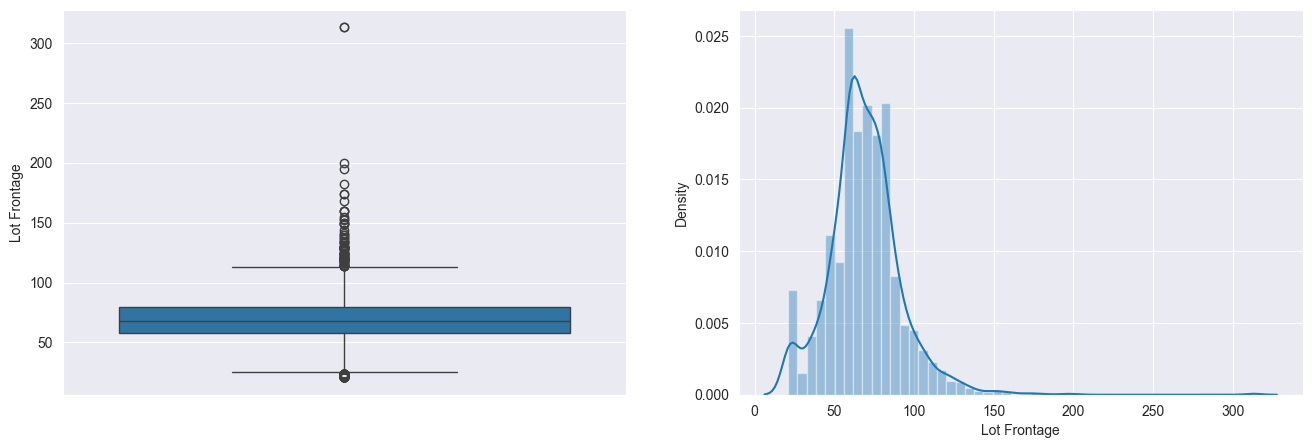

In [433]:
boxhistplot(df["Lot Frontage"])

In [434]:
lotfrontage_mean=df["Lot Frontage"].mean()
df_mvi["Lot Frontage"].replace(np.nan, lotfrontage_mean, inplace=True)
df_mvi["Lot Frontage"].isnull().sum()


0

In [435]:
def oldNewBoxHistPlot(df,df_new, feature, figsize=(16, 10)):
    plt.figure(figsize=figsize)
    plt.subplot(221)
    sns.boxplot(df[feature])
    plt.title("Old data distribution")
    plt.subplot(222)
    sns.distplot(df[feature])
    plt.title("Old data distribution")

    plt.subplot(223)
    sns.boxplot(df_new[feature])
    plt.title("Old data distribution")
    plt.subplot(224)
    sns.distplot(df_new[feature])
    plt.title("Old data distribution")



/var/folders/ps/8m068t8n4wg8plb13ns3t63r0000gn/T/ipykernel_64721/3150663914.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature])
/var/folders/ps/8m068t8n4wg8plb13ns3t63r0000gn/T/ipykernel_64721/3150663914.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_new[feature])


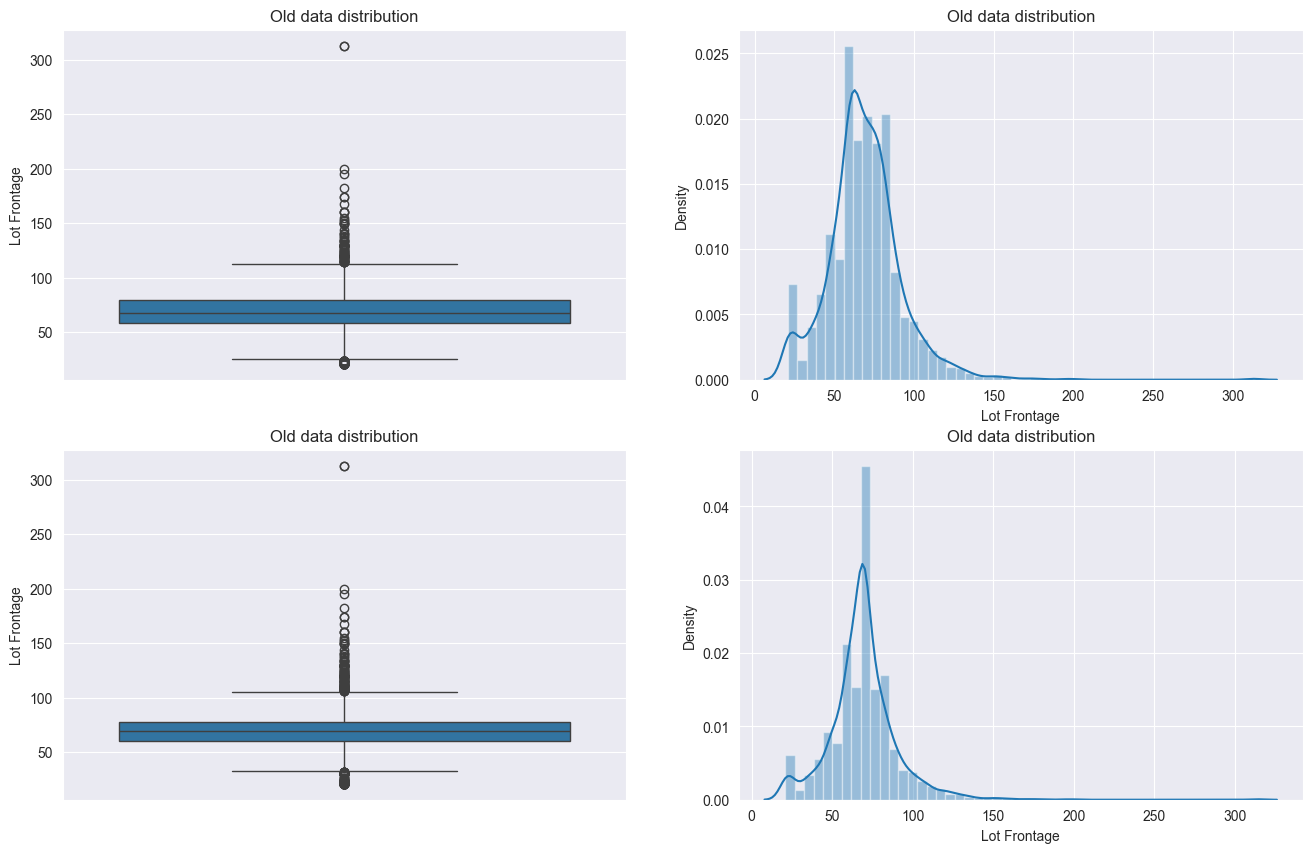

In [436]:
oldNewBoxHistPlot(df, df_mvi, "Lot Frontage")

Handling Mas Vnr Type      60.580205 Mas Vnr Area       0.784983

In [437]:
result = df.loc[
    df[["Mas Vnr Type", "Mas Vnr Area"]].isnull().any(axis=1),
    ["Mas Vnr Type", "Mas Vnr Area"]
]

pd.set_option('display.max_rows', None)
print(result)


     Mas Vnr Type  Mas Vnr Area
1             NaN           0.0
3             NaN           0.0
4             NaN           0.0
6             NaN           0.0
7             NaN           0.0
8             NaN           0.0
9             NaN           0.0
10            NaN           0.0
11            NaN           0.0
12            NaN           0.0
13            NaN           0.0
14            NaN           0.0
16            NaN           0.0
18            NaN           0.0
22            NaN           0.0
24            NaN           0.0
25            NaN           0.0
26            NaN           0.0
27            NaN           0.0
28            NaN           0.0
32            NaN           0.0
33            NaN           0.0
34            NaN           0.0
35            NaN           0.0
51            NaN           0.0
54            NaN           0.0
55            NaN           NaN
56            NaN           0.0
57            NaN           0.0
67            NaN           0.0
68      

In [438]:
df["Mas Vnr Type"].value_counts()

Mas Vnr Type
BrkFace    880
Stone      249
BrkCmn      25
CBlock       1
Name: count, dtype: int64

In [439]:
df["Mas Vnr Type"].isnull().sum()

1775

In [440]:
df[df["Mas Vnr Type"].isnull()][["Mas Vnr Type", "Mas Vnr Area"]].head()

,Mas Vnr Type,Mas Vnr Area
1,NaN,0.0
3,NaN,0.0
4,NaN,0.0
6,NaN,0.0
7,NaN,0.0


In [441]:
df["Mas Vnr Area"].isnull().sum()

23

In [442]:
df_mvi["Mas Vnr Type"] = df_mvi["Mas Vnr Type"].fillna("None")
df_mvi["Mas Vnr Area"] = df_mvi["Mas Vnr Area"].fillna(0)

In [443]:
df_mvi[df_mvi["Mas Vnr Type"].isnull()]["Mas Vnr Area"].value_counts()

Series([], Name: count, dtype: int64)

In [444]:
df_mvi["Mas Vnr Area"].isnull().sum()
df_mvi["Mas Vnr Type"].isnull().sum()

0

Handling Bsmnt features

In [445]:
cat_bsmt_feat=["Bsmt Qual",
"Bsmt Cond",
"Bsmt Exposure",
"BsmtFin Type 1",
"BsmtFin Type 2",]

num_bsmt_feat=["BsmtFin SF 1",
"BsmtFin SF 2",
"Bsmt Unf SF",
"Total Bsmt SF",
"Bsmt Full Bath" ,
"Bsmt Half Bath"]

<Axes: >

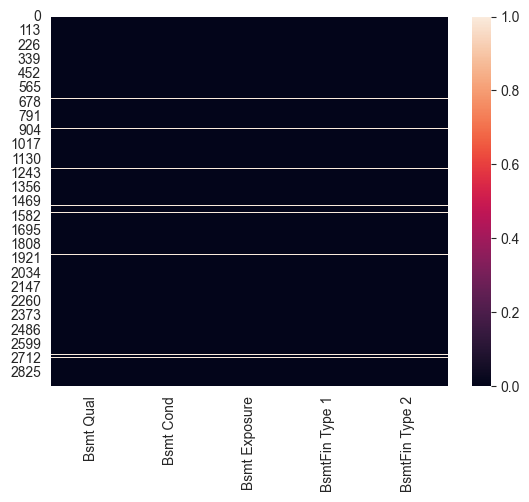

In [446]:
sns.heatmap(df[cat_bsmt_feat].isnull())

In [447]:
for feat in cat_bsmt_feat:
    print(f"Value count of {feat}: {df[feat].value_counts()}")

Value count of Bsmt Qual: Bsmt Qual
TA    1283
Gd    1219
Ex     258
Fa      88
Po       2
Name: count, dtype: int64
Value count of Bsmt Cond: Bsmt Cond
TA    2616
Gd     122
Fa     104
Po       5
Ex       3
Name: count, dtype: int64
Value count of Bsmt Exposure: Bsmt Exposure
No    1906
Av     418
Gd     284
Mn     239
Name: count, dtype: int64
Value count of BsmtFin Type 1: BsmtFin Type 1
GLQ    859
Unf    851
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: count, dtype: int64
Value count of BsmtFin Type 2: BsmtFin Type 2
Unf    2499
Rec     106
LwQ      89
BLQ      68
ALQ      53
GLQ      34
Name: count, dtype: int64


In [448]:
for null_values in cat_bsmt_feat:
    print(f"null values of{null_values}: {df[null_values].isnull().sum()}")

null values ofBsmt Qual: 80
null values ofBsmt Cond: 80
null values ofBsmt Exposure: 83
null values ofBsmtFin Type 1: 80
null values ofBsmtFin Type 2: 81


In [449]:
bsmt_count="NA"
for feat in cat_bsmt_feat:
    df_mvi[feat].replace(np.nan, "bsmt_count", inplace=True)

In [450]:
df_mvi[cat_bsmt_feat].isnull().sum()

Bsmt Qual         0
Bsmt Cond         0
Bsmt Exposure     0
BsmtFin Type 1    0
BsmtFin Type 2    0
dtype: int64

<Axes: >

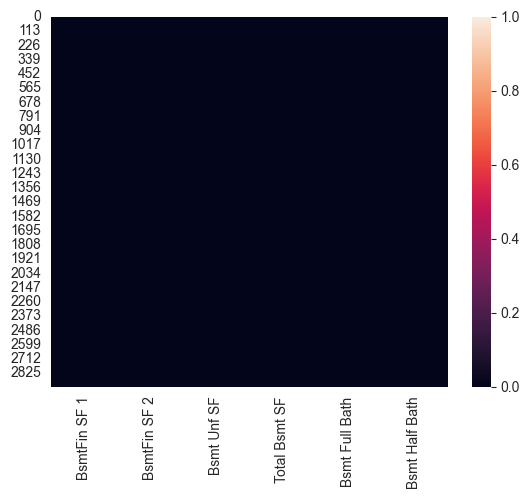

In [451]:
sns.heatmap(df[num_bsmt_feat].isnull())

In [452]:
df_bsmt=df[cat_bsmt_feat+num_bsmt_feat]
df_bsmt[df_bsmt.isnull().any(axis=1)]

,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Bsmt Full Bath,Bsmt Half Bath
66,Gd,TA,NaN,Unf,Unf,0.0,0.0,1595.0,1595.0,0.0,0.0
83,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
154,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
206,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
243,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
273,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
275,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
290,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
444,Gd,TA,No,GLQ,NaN,1124.0,479.0,1603.0,3206.0,1.0,0.0
551,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


In [453]:
bsmt_num=0
for feat in num_bsmt_feat:
    df_mvi[feat].replace(np.nan, "bsmt_num", inplace=True)


In [454]:
df_mvi[num_bsmt_feat].isnull().sum()

BsmtFin SF 1      0
BsmtFin SF 2      0
Bsmt Unf SF       0
Total Bsmt SF     0
Bsmt Full Bath    0
Bsmt Half Bath    0
dtype: int64

Handling Electrical         0.034130

In [455]:
df["Electrical"].value_counts()

Electrical
SBrkr    2682
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: count, dtype: int64

In [456]:
df["Electrical"].isnull().any()

True

| Situation                        | Action           |
| -------------------------------- | ---------------- |
| Numeric feature                  | Mean/Median      |
| Categorical feature              | Mode             |
| Structural missing               | Fill with "None" |
| Extremely high missing & useless | Drop             |


In [457]:
df_mvi["Electrical"] = df_mvi["Electrical"].fillna(df_mvi["Electrical"].mode()[0])


In [458]:
df_mvi["Electrical"].isnull().any()

False

Handling remaining cat features Fireplace Qu

In [459]:
df["Fireplace Qu"].isnull().sum()

1422

In [460]:
df["Fireplace Qu"].value_counts()

Fireplace Qu
Gd    744
TA    600
Fa     75
Po     46
Ex     43
Name: count, dtype: int64

In [461]:
df_mvi["Fireplace Qu"]=df_mvi["Fireplace Qu"].fillna("None")

In [462]:
df_mvi["Fireplace Qu"].isnull().sum()

0

Handling Pool QC           99.556314
Fence             80.477816
Misc Feature      96.382253

In [463]:
cat_feat=["Pool QC","Fence","Misc Feature"]

for col in cat_feat:
    print(f"value counts of {col}: {df[col].value_counts()}")

value counts of Pool QC: Pool QC
Ex    4
Gd    4
TA    3
Fa    2
Name: count, dtype: int64
value counts of Fence: Fence
MnPrv    330
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64
value counts of Misc Feature: Misc Feature
Shed    95
Gar2     5
Othr     4
Elev     1
TenC     1
Name: count, dtype: int64


In [464]:
for col in cat_feat:
    df_mvi[col]=df_mvi[col].fillna("NA")

In [465]:
df_mvi[cat_feat].isnull().sum()

Pool QC         0
Fence           0
Misc Feature    0
dtype: int64

Handling Garage Type        5.358362
Garage Finish      5.426621
Garage Qual        5.426621
Garage Cond        5.426621

In [466]:
cat_garage_feat=["Garage Type",
"Garage Finish",
"Garage Qual",
"Garage Cond"]

num_garage_feat=["Garage Yr Blt",
"Garage Cars",
"Garage Area"]

df_garage=df[cat_garage_feat+num_garage_feat]



In [467]:
for col in cat_garage_feat:
    #for cat features
    df_mvi[col].replace(np.nan, "NA", inplace=True)

In [468]:
for col in num_garage_feat:
    df_mvi[col].replace(np.nan, 0, inplace=True)

In [469]:
df_mvi[cat_garage_feat].isnull().sum()


Garage Type      0
Garage Finish    0
Garage Qual      0
Garage Cond      0
dtype: int64

In [470]:
df_mvi[num_garage_feat].isnull().sum()

Garage Yr Blt    0
Garage Cars      0
Garage Area      0
dtype: int64

In [471]:
df_mvi.isnull().any(axis=1).sum()

0

Feature Transformation
Convert numerical feature to Categorical

In [472]:
for_num_conversion=["MS SubClass","Year Built","Year Remod/Add","Garage Yr Blt",'Mo Sold',"Yr Sold"]
for feat in for_num_conversion:
    print(f"{feat}: data type={df[feat].dtype}")

MS SubClass: data type=int64
Year Built: data type=int64
Year Remod/Add: data type=int64
Garage Yr Blt: data type=float64
Mo Sold: data type=int64
Yr Sold: data type=int64


In [473]:
df_mvi[for_num_conversion].head()

,MS SubClass,Year Built,Year Remod/Add,Garage Yr Blt,Mo Sold,Yr Sold
0,20,1960,1960,1960.0,5,2010
1,20,1961,1961,1961.0,6,2010
2,20,1958,1958,1958.0,6,2010
3,20,1968,1968,1968.0,4,2010
4,60,1997,1998,1997.0,3,2010


In [474]:
calendar.month_abbr[12]

'Dec'

In [475]:
df_mvi["Mo Sold"].apply(lambda x : calendar.month_abbr[x])

0       May
1       Jun
2       Jun
3       Apr
4       Mar
5       Jun
6       Apr
7       Jan
8       Mar
9       Jun
10      Apr
11      Mar
12      May
13      Feb
14      Jun
15      Jun
16      Jun
17      Jun
18      Jun
19      Feb
20      Jan
21      Jan
22      Jan
23      Mar
24      Apr
25      Jul
26      Apr
27      Apr
28      Jun
29      Feb
30      Mar
31      Mar
32      Jul
33      Jun
34      Jun
35      Jul
36      Jan
37      May
38      Apr
39      Jun
40      May
41      Jun
42      Feb
43      Mar
44      Mar
45      Jun
46      Jun
47      Jun
48      Feb
49      Apr
50      Jun
51      Jan
52      Jan
53      Apr
54      Jun
55      May
56      Apr
57      Apr
58      May
59      May
60      Jan
61      Mar
62      Apr
63      Apr
64      Jun
65      Mar
66      May
67      Apr
68      Jun
69      Apr
70      May
71      May
72      Jan
73      Apr
74      May
75      May
76      May
77      Apr
78      Feb
79      Feb
80      May
81      Apr
82      Apr
83  

In [476]:
df_mvi["Mo Sold"].unique()

array([ 5,  6,  4,  3,  1,  2,  7, 10,  8, 11,  9, 12])

In [477]:
for feat in for_num_conversion:
    df_mvi[feat]=df_mvi[feat].astype(str)

In [478]:
for feat in for_num_conversion:
    print(f"{feat}: data type={df_mvi[feat].dtype}")

MS SubClass: data type=object
Year Built: data type=object
Year Remod/Add: data type=object
Garage Yr Blt: data type=object
Mo Sold: data type=object
Yr Sold: data type=object


Convert categorical features into numerical
Ordinal Encoding

In [479]:
ordinal_enco_var = [
    # Shape / Slope / Level
    "Lot Shape",          # Reg > IR1 > IR2 > IR3
    "Land Slope",         # Gtl > Mod > Sev
    # Overall ratings (already numeric but ordinal in meaning)
    "OverallQual",
    "OverallCond",
    # Exterior quality
    "ExterQual",
    "ExterCond",
    # Basement
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    # Heating quality
    "HeatingQC",
    # Kitchen quality
    "KitchenQual",
    # Functionality (clear ranking)
    "Functional",
    # Fireplace quality
    "FireplaceQu",
    # Garage
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    # Driveway quality
    "PavedDrive",
    # Pool quality
    "PoolQC",
    # Fence quality
    "Fence"
]
len(ordinal_enco_var)

21

In [480]:
df_mvi["Lot Shape"].value_counts()

Lot Shape
Reg    1859
IR1     979
IR2      76
IR3      16
Name: count, dtype: int64

In [481]:
df_mvi["Lot Shape"]=df_mvi["Lot Shape"].astype(CategoricalDtype( categories=["IR3","IR2","IR1","Reg"],ordered=True)).cat.codes

In [482]:
df_mvi["Lot Shape"].value_counts()

Lot Shape
3    1859
2     979
1      76
0      16
Name: count, dtype: int64

In [483]:
df_mvi["Land Slope"].value_counts()

Land Slope
Gtl    2789
Mod     125
Sev      16
Name: count, dtype: int64

In [484]:
df_mvi["Land Slope"]=df_mvi["Land Slope"].astype(CategoricalDtype( categories=["Sev","Mod","Gtl"],ordered=True)).cat.codes

In [485]:
df_mvi["Land Slope"].value_counts()

Land Slope
2    2789
1     125
0      16
Name: count, dtype: int64

In [486]:

# Exterior Quality / Condition
quality_order = ["Po", "Fa", "TA", "Gd", "Ex"]
df_mvi["Exter Qual"] = df_mvi["Exter Qual"].astype(CategoricalDtype(quality_order, ordered=True)).cat.codes
df_mvi["Exter Cond"] = df_mvi["Exter Cond"].astype(CategoricalDtype(quality_order, ordered=True)).cat.codes

# Basement
bsmt_qual_order = ["NA", "Po", "Fa", "TA", "Gd", "Ex"]
df_mvi["Bsmt Qual"] = df_mvi["Bsmt Qual"].astype(CategoricalDtype(bsmt_qual_order, ordered=True)).cat.codes
df_mvi["Bsmt Cond"] = df_mvi["Bsmt Cond"].astype(CategoricalDtype(bsmt_qual_order, ordered=True)).cat.codes

bsmt_exposure_order = ["NA", "No", "Mn", "Av", "Gd"]
df_mvi["Bsmt Exposure"] = df_mvi["Bsmt Exposure"].astype(CategoricalDtype(bsmt_exposure_order, ordered=True)).cat.codes

bsmt_fin_order = ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"]
df_mvi["BsmtFin Type 1"] = df_mvi["BsmtFin Type 1"].astype(CategoricalDtype(bsmt_fin_order, ordered=True)).cat.codes
df_mvi["BsmtFin Type 2"] = df_mvi["BsmtFin Type 2"].astype(CategoricalDtype(bsmt_fin_order, ordered=True)).cat.codes

# Heating Quality
df_mvi["Heating QC"] = df_mvi["Heating QC"].astype(CategoricalDtype(quality_order, ordered=True)).cat.codes

# Kitchen Quality
df_mvi["Kitchen Qual"] = df_mvi["Kitchen Qual"].astype(CategoricalDtype(quality_order, ordered=True)).cat.codes

# Functional
functional_order = ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"]
df_mvi["Functional"] = df_mvi["Functional"].astype(CategoricalDtype(functional_order, ordered=True)).cat.codes

# Fireplace Quality
fireplace_order = ["NA", "Po", "Fa", "TA", "Gd", "Ex"]
df_mvi["Fireplace Qu"] = df_mvi["Fireplace Qu"].astype(CategoricalDtype(fireplace_order, ordered=True)).cat.codes

# Garage
garage_finish_order = ["NA", "Unf", "RFn", "Fin"]
df_mvi["Garage Finish"] = df_mvi["Garage Finish"].astype(CategoricalDtype(garage_finish_order, ordered=True)).cat.codes

garage_qual_order = ["NA", "Po", "Fa", "TA", "Gd", "Ex"]
df_mvi["Garage Qual"] = df_mvi["Garage Qual"].astype(CategoricalDtype(garage_qual_order, ordered=True)).cat.codes
df_mvi["Garage Cond"] = df_mvi["Garage Cond"].astype(CategoricalDtype(garage_qual_order, ordered=True)).cat.codes

# Paved Drive
paved_order = ["N", "P", "Y"]
df_mvi["Paved Drive"] = df_mvi["Paved Drive"].astype(CategoricalDtype(paved_order, ordered=True)).cat.codes

# Pool Quality
pool_order = ["NA", "Fa", "TA", "Gd", "Ex"]
df_mvi["Pool QC"] = df_mvi["Pool QC"].astype(CategoricalDtype(pool_order, ordered=True)).cat.codes

# Fence
fence_order = ["NA", "MnWw", "GdWo", "MnPrv", "GdPrv"]
df_mvi["Fence"] = df_mvi["Fence"].astype(CategoricalDtype(fence_order, ordered=True)).cat.codes


In [487]:
df_mvi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   object 
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2930 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            2930 non-null   object 
 8   Lot Shape        2930 non-null   int8   
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   int8   
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

One hot encoding for nominal categorical data

In [488]:
df_encod=df_mvi.copy()
object_features=df_encod.select_dtypes(include="object").columns.tolist()
print(object_features)
len(object_features)

['MS SubClass', 'MS Zoning', 'Street', 'Alley', 'Land Contour', 'Utilities', 'Lot Config', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Foundation', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Central Air', 'Electrical', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Type', 'Garage Yr Blt', 'Misc Feature', 'Mo Sold', 'Yr Sold', 'Sale Type', 'Sale Condition']


36

In [489]:
df_encod[object_features].head(2)

,MS SubClass,MS Zoning,Street,Alley,Land Contour,Utilities,Lot Config,Neighborhood,Condition 1,Condition 2,...,Electrical,Bsmt Full Bath,Bsmt Half Bath,Garage Type,Garage Yr Blt,Misc Feature,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,20,RL,Pave,alley_constant,Lvl,AllPub,Corner,NAmes,Norm,Norm,...,SBrkr,1.0,0.0,Attchd,1960.0,NA,5,2010,WD,Normal
1,20,RH,Pave,alley_constant,Lvl,AllPub,Inside,NAmes,Feedr,Norm,...,SBrkr,0.0,0.0,Attchd,1961.0,NA,6,2010,WD,Normal


In [490]:
print("shape of DF before encoding:",df_encod.shape)
df_encod=pd.get_dummies(df_encod,columns=object_features,prefix=object_features,drop_first=True)
print(("Shape of DF after encoding:",df_encod.shape))

shape of DF before encoding: (2930, 82)
('Shape of DF after encoding:', (2930, 3985))


In [491]:
df_encod["SalePrice"].dtype

dtype('int64')

In [492]:
df_encod.select_dtypes(include="object").columns.tolist()

[]

Split DAta for Training and Testing

In [493]:
df_encod.shape

(2930, 3985)

In [494]:
X = df_encod.drop("SalePrice", axis=1)
y = df_encod["SalePrice"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape

(2344, 3984)

In [495]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Feature Scaling

In [496]:
# X_train_scaled[:3,:]

In [497]:
# X_test_scaled[:3,:]

In [498]:
# Carry Forward for Deployment
# scaler.mean_.shape
# scaler.n_features_in_
# len(scaler.n_samples_seen_)
# scaler.scale_
# scaler.var_
# scaler.with_mean
# scaler.with_std

TRAIN ML MODEL

In [499]:
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

In [500]:
svr = SVR()
lr = LinearRegression()
sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
knr = KNeighborsRegressor()
gpr = GaussianProcessRegressor()
dtr = DecisionTreeRegressor()
gbr = GradientBoostingRegressor()
rfr = RandomForestRegressor()
mlpr = MLPRegressor()

In [501]:
models={"a":["LinearRegression",lr],
        "b":["SVR",svr],
        "c":["SGDRegressor",sgd],
        "d":["KNeighborsRegressor",knr],
        "e":["GaussianProcessRegressor",gpr],
        "f":["DecisionTreeRegressor",dtr],
        "g":["GradientBoostingRegressor",gbr],
        "h":["RandomForestRegressor",rfr],
        "j":["MLRegressor",mlpr],
}

In [502]:
from sklearn.metrics import r2_score, mean_squared_error

results = []

for key, value in models.items():

    name = value[0]
    model = value[1]

    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append((name, r2, rmse))

    print(f"{name} Results")
    print(f"R2 Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    print("-"*40)

Training LinearRegression...
LinearRegression Results
R2 Score: 0.0779
RMSE: 85982.43
----------------------------------------
Training SVR...
SVR Results
R2 Score: -0.1097
RMSE: 94325.82
----------------------------------------
Training SGDRegressor...
SGDRegressor Results
R2 Score: -123700024670268.3906
RMSE: 995876938606.55
----------------------------------------
Training KNeighborsRegressor...
KNeighborsRegressor Results
R2 Score: -0.3237
RMSE: 103018.71
----------------------------------------
Training GaussianProcessRegressor...
GaussianProcessRegressor Results
R2 Score: -4.4621
RMSE: 209266.56
----------------------------------------
Training DecisionTreeRegressor...
DecisionTreeRegressor Results
R2 Score: 0.8517
RMSE: 34483.04
----------------------------------------
Training GradientBoostingRegressor...
GradientBoostingRegressor Results
R2 Score: 0.9134
RMSE: 26352.01
----------------------------------------
Training RandomForestRegressor...
RandomForestRegressor Results
R2 S

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Retraining Random Forest Regressor as it gives higest accuracy = 90 after dropping PID

In [512]:
print(X_train.columns)

Index(['Order', 'Lot Frontage', 'Lot Area', 'Lot Shape', 'Land Slope',
       'Overall Qual', 'Overall Cond', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond',
       ...
       'Sale Type_ConLw', 'Sale Type_New', 'Sale Type_Oth', 'Sale Type_VWD',
       'Sale Type_WD ', 'Sale Condition_AdjLand', 'Sale Condition_Alloca',
       'Sale Condition_Family', 'Sale Condition_Normal',
       'Sale Condition_Partial'],
      dtype='object', length=3983)


In [521]:
best_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score
print("Final R2:", r2_score(y_test, y_pred))

Final R2: 0.9070315450090689


In [522]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

Overall Qual      0.604534
Gr Liv Area       0.102526
1st Flr SF        0.058128
2nd Flr SF        0.022075
Garage Cars       0.018493
Full Bath         0.018028
Lot Area          0.016585
Garage Area       0.016430
Kitchen Qual      0.009701
BsmtFin Type 1    0.007938
dtype: float64


Cross Validation

In [523]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross Validation Scores:", scores)
print("Mean CV Score:", scores.mean())

Cross Validation Scores: [0.89416659 0.91654939 0.86625781 0.81768147 0.90008712]
Mean CV Score: 0.8789484743775189


Now for better imporovement we to HYPERPARAMETER TUNING using randomsearchCV rather than gridsearchCV because RSCV is faster

In [525]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    "n_estimators": np.arange(200, 800, 100),
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}
Best CV Score: 0.8763540061099586


Retraining the model with best parameter features in which it performs as given above i.e. Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}

In [528]:
best_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

y_pred = best_rf.predict(X_test)

from sklearn.metrics import r2_score

print("Final R2:", r2_score(y_test, y_pred))

Final R2: 0.9056131002225768


Saving the trained model

In [530]:
print(best_rf)

RandomForestRegressor(max_depth=20, max_features=None, n_estimators=500,
                      n_jobs=-1, random_state=42)


In [531]:
import joblib

joblib.dump(best_rf, "../models/house_price_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['scaler.pkl']

In [532]:
import os
print(os.listdir())

['eda.ipynb', 'scaler.pkl', 'house_price_model.pkl']
